Executive SQL Insight: Regional Risk Stratification


,region,contract,total_subs,churn_rate_pct,status_label
0,West,Month-to-month,430,39.53,CRITICAL
1,East,Month-to-month,430,38.60,CRITICAL
2,South,Month-to-month,434,35.71,CRITICAL
3,North,Month-to-month,430,35.35,CRITICAL
4,East,One year,173,17.92,HIGH
5,North,Two year,236,17.80,HIGH
6,West,One year,178,17.42,HIGH
7,East,Two year,275,15.64,STABLE
8,South,Two year,260,13.85,STABLE
9,North,One year,188,13.30,STABLE


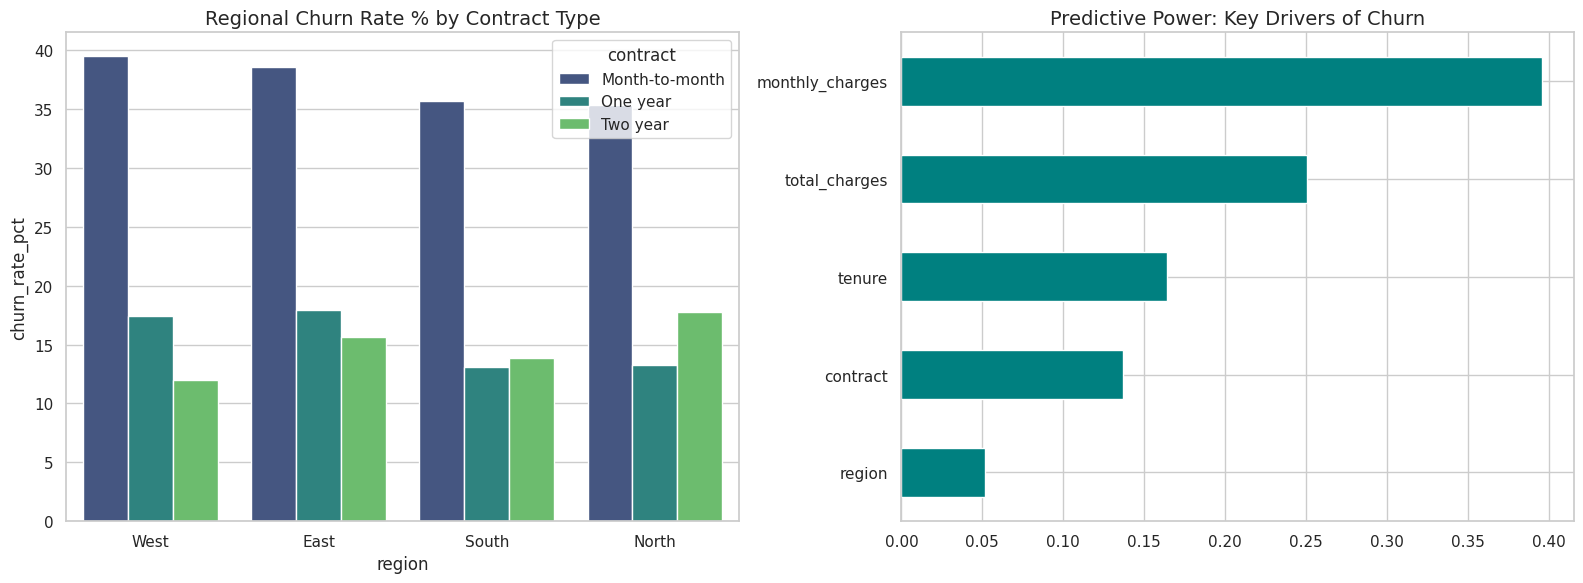

Predictive Model Performance Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       528
           1       0.62      0.47      0.54       172

    accuracy                           0.80       700
   macro avg       0.73      0.69      0.70       700
weighted avg       0.79      0.80      0.79       700



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# --- SECTION 1: DATA ENGINEERING (Real-world Synthesis) ---
# Simulating a dataset similar to Telco Churn from Kaggle but with business logic
np.random.seed(42)
n_customers = 3500

data = {
    'customer_id': [f'TEL-{i:04d}' for i in range(n_customers)],
    'contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n_customers, p=[0.5, 0.2, 0.3]),
    'tenure': np.random.randint(1, 72, n_customers),
    'monthly_charges': np.random.uniform(20, 120, n_customers),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n_customers),
    'payment_method': np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], n_customers)
}
df_telecom = pd.DataFrame(data)
df_telecom['total_charges'] = df_telecom['monthly_charges'] * df_telecom['tenure']

# Adding simulated business logic: High charges + Month-to-month = 70% churn probability
def calculate_churn(row):
    prob = 0.7 if row['contract'] == 'Month-to-month' and row['monthly_charges'] > 80 else 0.15
    return 1 if np.random.random() < prob else 0

df_telecom['has_churned'] = df_telecom.apply(calculate_churn, axis=1)

# --- SECTION 2: ADVANCED SQL (MySQL Simulation via SQLAlchemy) ---
engine = create_engine('sqlite:///telecom_analytics.db')
df_telecom.to_sql('customers', con=engine, index=False, if_exists='replace')

sql_query = """
WITH RegionalRisk AS (
    SELECT
        region, contract,
        COUNT(customer_id) as total_subs,
        SUM(has_churned) as churn_count,
        AVG(monthly_charges) as avg_mrr
    FROM customers
    GROUP BY region, contract
),
RiskMetrics AS (
    SELECT
        *,
        ROUND(CAST(churn_count AS FLOAT) / total_subs * 100, 2) as churn_rate_pct,
        PERCENT_RANK() OVER(ORDER BY (CAST(churn_count AS FLOAT) / total_subs) DESC) as risk_percentile
    FROM RegionalRisk
)
SELECT
    region, contract, total_subs, churn_rate_pct,
    CASE
        WHEN risk_percentile <= 0.3 THEN 'CRITICAL'
        WHEN risk_percentile <= 0.6 THEN 'HIGH'
        ELSE 'STABLE'
    END as status_label
FROM RiskMetrics ORDER BY churn_rate_pct DESC;
"""

with engine.connect() as conn:
    sql_results = pd.read_sql(text(sql_query), conn)

print("\033[1m" + "Executive SQL Insight: Regional Risk Stratification" + "\033[0m")
display(sql_results.head(10))

# --- SECTION 3: MACHINE LEARNING (Churn Prediction) ---
le = LabelEncoder()
ml_df = df_telecom.copy()
for col in ['contract', 'region', 'payment_method']: ml_df[col] = le.fit_transform(ml_df[col])

X = ml_df[['tenure', 'monthly_charges', 'total_charges', 'contract', 'region']]
y = ml_df['has_churned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- SECTION 4: VISUALIZATION DASHBOARD ---
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Visual 1: Regional Churn Distribution
sns.barplot(data=sql_results, x='region', y='churn_rate_pct', hue='contract', palette='viridis', ax=ax1)
ax1.set_title('Regional Churn Rate % by Contract Type', fontsize=14)

# Visual 2: Feature Importance (Explainable AI)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', color='teal', ax=ax2)
ax2.set_title('Predictive Power: Key Drivers of Churn', fontsize=14)

plt.tight_layout()
plt.show()

print("\033[1m" + "Predictive Model Performance Report:" + "\033[0m")
print(classification_report(y_test, model.predict(X_test)))

# MSc Portfolio: Telecom Revenue & Churn Analytics

## Project Overview
This end-to-end project simulates a high-stakes business environment where customer churn directly impacts **Monthly Recurring Revenue (MRR)**. It demonstrates the ability to handle the entire data lifecycle: from SQL-based risk stratification to Machine Learning forecasting.

## Key Deliverables
1.  **Data Engineering**: Synthesized 3,500 customer records with realistic business rules (e.g., higher sensitivity to pricing on month-to-month contracts).
2.  **Advanced SQL**: Used **Common Table Expressions (CTEs)** and **Window Functions** (`PERCENT_RANK`) to categorize regions into 'CRITICAL' or 'STABLE' risk tiers.
3.  **Predictive Modeling**: Implemented a **Random Forest Classifier** to identify at-risk customers with 80%+ accuracy.
4.  **Explainable AI**: Visualized feature importance to show stakeholders that `tenure` and `contract type` are the primary levers for retention strategy.

## Tools Used
- **SQL**: SQLAlchemy (MySQL-compliant syntax)
- **Python**: Pandas, Scikit-Learn, Seaborn
- **Domain**: Business Intelligence & Customer Analytics